In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp

In [2]:
## Define linear e.o.s.
def rho_eq(S, T):
    return 1000 + S * (0.7718) - T * (0.17765) 

In [6]:
def inner_plume(z, y, Q_o, M_o, T_o, S_o):
    # state: y[0]=Q_i, y[1]=M_i, y[2]=T_tot (=Q_i * T_i), y[3]=S_tot (=Q_i * S_i)
    Q_i = y[0]
    M_i = y[1]
    T_tot = y[2]
    S_tot = y[3]

    # numerical floors (prevent division by zero / blow-ups)
    # Q_floor = 1e-6
    # u_floor = 1e-6
    # Q_i = max(Q_i, Q_floor)

    T_i = T_tot / Q_i    # concentration (°C)
    S_i = S_tot / Q_i    # concentration (PSU)

    # prevent unphysical salinity/temperature values (optional clamp)
    # S_i = np.clip(S_i, 0, 40)
    # T_i = np.clip(T_i, -5, 30)

    # velocities and width
    u_i = M_i / Q_i
    # u_i = np.sign(u_i) * max(abs(u_i), u_floor)  # keep sign but avoid zero

    if Q_o == 0:
        u_o = 0.0
        b_o = 0.0
    else:
        u_o = M_o / Q_o
        b_o = (Q_o**2/(math.pi * M_o) + (Q_i/np.sqrt(math.pi*M_i))**2 )**0.5

    b_i = Q_i / np.sqrt(math.pi * M_i)  # protect sqrt arg

    # densities (ensure rho_eq expects PSU, degC)
    rho_i = rho_eq(S_i, T_i)

    # parameters (as in your code)
    chi = 0.0001
    rho_b = 1.204
    rho_a = 1024.
    rho_r = 1024.
    rho_m = chi * rho_b + (1-chi) * rho_i

    c1 = 1.0
    eps = 0.015
    u_s = 0.1
    alpha_a = 0.110
    alpha_o = 0.110
    alpha_i = 0.055
    gamma = 1.1
    lam = 1.0
    g = 9.81

    # buoyancy / production
    # avoid negative sqrt or nonsense -> ensure physical ranges
    B_i = g * (rho_a - rho_i) / rho_r * math.pi * b_i**2 * u_i

    # entrainment fluxes (volumetric: m^3/s per unit length)
    E_i = 2.0 * math.pi * b_i * alpha_i * (abs(u_i) + c1 * abs(u_o))

    # E_o/E_a should be zero if u_o == 0, otherwise remove mass from inner if outer pulls
    if abs(u_o) < 1e-12:
        E_o = 0.0
        E_a = 0.0
    else:
        E_o = 2.0 * math.pi * b_i * alpha_o * abs(u_o)
        E_a = 2.0 * math.pi * b_o * alpha_a * abs(u_o)

    # plume production / detrainment (make sign remove mass if positive)
    # ensure no division by zero in u_i
    E_p = -eps * (u_s / u_i)**2 * g * (rho_a - rho_i) / rho_r * math.pi * b_i**2 / u_i

    # gravitational production term used in momentum eqn
    g_flux = math.pi * g * b_i**2 * (lam**2 * (rho_a - rho_m)) / (gamma * rho_r)

    # mass (Q) and momentum (M) tendencies
    dQidz = E_i - E_o - E_p
    dMidz = g_flux + E_i * u_o - E_o * u_i - E_p * u_i

    # Conservative salt & heat evolution: d(Q*S)/dz = E_i*S_o - E_o*S_i - E_p*S_i
    dS_tot_dz = E_i * S_o - E_o * S_i - E_p * S_i
    dT_tot_dz = E_i * T_o - E_o * T_i - E_p * T_i

    return np.array([dQidz, dMidz, dT_tot_dz, dS_tot_dz])

In [7]:
def outer_plume(t, y, Q_i, M_i, T_i, S_i):

    Q_o = y[0]
    M_o = y[1]
    T_o = y[2]
    S_o = y[3]

    b_i = Q_i / np.sqrt(math.pi * M_i)
    u_i = M_i / Q_i
    if Q_o == 0:
        u_o = 0
        b_o = 0
    else:
        u_o = M_o / Q_o
        b_o = (Q_o**2/(math.pi * M_o) + b_i**2)**(1/2)

    chi = 0.1
    T_a = 2
    S_a = 34
    rho_i = 1000
    rho_b = 1.204
    rho_a = 1024
    rho_r = 1024
    rho_o = 1010
    rho_m = chi * rho_b + (1-chi) * rho_i
    cp = 4019
    c1 = 1
    c2 = 1
    eps = 0.015
    u_s = 0.1
    alpha_a = 0.110
    gamma = 1.1
    gamma_o = 1.1

    B_i = g * (rho_a - rho_i)/(rho_r) * math.pi * b_i**2 * u_i

    E_i = 2 * math.pi * b_i * alpha_i * (u_i + c1 * u_o)
    E_o = -2 * math.pi * b_i * alpha_o * u_o
    E_a = -2 * math.pi * b_o * alpha_a * u_o
    E_p = -c2 * eps * (u_s / u_i)**2 * (B_i / u_i**2)

    # print(E_p)

    dQo_dz = E_a + E_o - E_i + E_p

    dMo_dz = math.pi * g * (b_o**2 - b_i**2) * (rho_o - rho_a) / (gamma_o * rho_r) + E_i * u_o - E_o * u_i - E_p * u_i

    dTo_dz = E_i * T_o - E_o * T_i - E_a * T_a - E_p * T_i

    dSo_dz = E_i * S_o - E_o * S_i - E_a * S_a - E_p * S_i

    return np.array([dQo_dz, dMo_dz, dTo_dz, dSo_dz])


Initial Vol. Flux = 314.1592653589793. Initial Mom. Flux = 314.1592653589793.


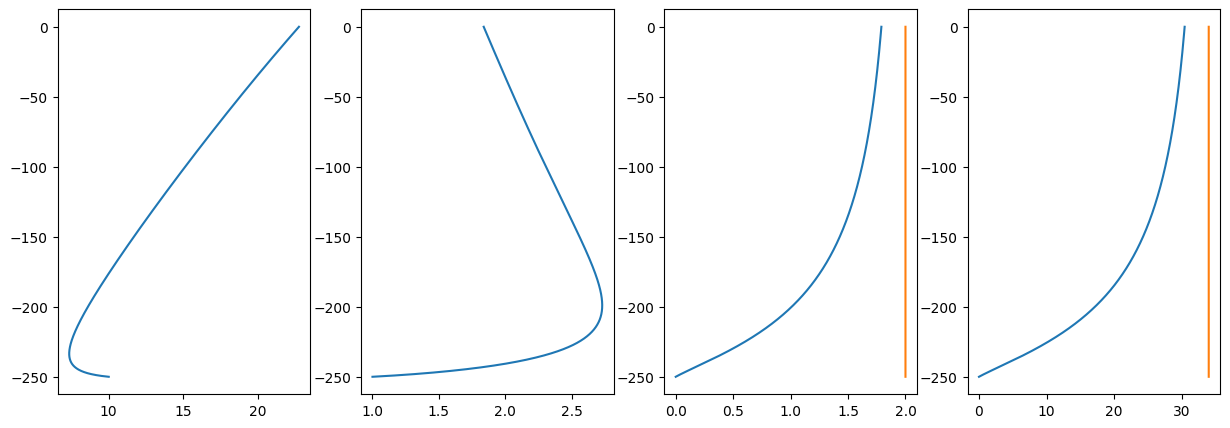

In [8]:
z_span = np.array([-250,0])
dz = 0.1
zLevels = np.arange(z_span[0], z_span[-1], dz)
Nz = len(zLevels)

bo_i = 10
uo_i = 1

Qo_i = bo_i**2 * uo_i * math.pi 
Mo_i = bo_i**2 * uo_i**2 * math.pi 
print(f"Initial Vol. Flux = {Qo_i}. Initial Mom. Flux = {Mo_i}.")
To_i = 0
So_i = 0

Ttot_i = To_i * Qo_i
Stot_i = So_i * Qo_i

y0 = np.array([Qo_i, Mo_i, Ttot_i, Stot_i])
T_a = 2
S_a = 34
sol = solve_ivp(inner_plume, z_span, y0, t_eval = zLevels, args=(0,0,T_a,S_a))

Qi = sol.y[0]
Mi = sol.y[1]
Ti = sol.y[2] / Qi
Si = sol.y[3] / Qi
z = sol.t

fig, ax = plt.subplots(1,4, figsize = (15,5))

ax[0].plot(Qi/np.sqrt(np.pi * Mi), z)
ax[1].plot(Mi/Qi, z)
ax[2].plot(Ti, z)
ax[2].plot(np.ones(Nz) * T_a,z)
ax[3].plot(Si, z)
ax[3].plot(np.ones(Nz) * S_a, z)

In [259]:
T_a = 2
S_a = 34
y0_inner = np.array([40, 20, 0, 0])
sol_inner = solve_ivp(inner_plume, z_span, y0_inner, t_eval = zLevels, args=(0,0, T_a, S_a))

Qo_i = -sol.y[0][-1]
b_i = sol.y[0][-1] / np.sqrt(math.pi * sol.y[1][-1])

b_o = 1.1 * b_i
u_o = -0.1 * np.sqrt((b_o - b_i) * g * abs(rho_a - rho_o) / rho_r)
print(b_o); 
print(u_o)
Mo_i = math.pi * u_o**2 * (b_o**2 - b_i**2)
print(Mo_i)

To_i = sol_inner.y[2][-1]
So_i = sol_inner.y[3][-1]
y0_outer = np.array([Qo_i ,Mo_i, To_i, So_i])
sol_outer = solve_ivp(outer_plume, z_span[::-1], y0_outer, t_eval = zLevels[::-1], args=(sol_inner.y[0][-1],sol_inner.y[1][-1], sol_inner.y[2][-1], sol_inner.y[3][-1]))

Qi_after = sol_inner.y[0]
Qo_after = sol_outer.y[0]

Mi_after = sol_inner.y[1]
Mo_after = sol_outer.y[1]

nIters = 5

for i in range(0,nIters):

    Qi_before = Qi_after
    Qo_before = Qo_after

    Mi_before = Mi_after
    Mo_before = Mo_after

    y0_inner = np.array([40, 20, 0, 0])
    sol_inner = solve_ivp(inner_plume, z_span, y0_inner, t_eval = zLevels, args=(sol_outer.y[0][0], sol_outer.y[1][0], sol_outer.y[2][0], sol_outer.y[3][0]))

    Qo_i = -sol.y[0][-1]
    b_i = sol.y[0][-1] / np.sqrt(math.pi * sol.y[1][-1])
    b_o = 1.1 * b_i
    u_o = -0.1 * np.sqrt((b_o - b_i) * g * abs(rho_a - rho_o) / rho_r)
    Mo_i = math.pi * u_o**2 * (b_o**2 - b_i**2)
    To_i = sol_inner.y[2][-1]
    So_i = sol_inner.y[3][-1]

    y0_outer = np.array([Qo_i ,Mo_i, To_i, So_i])
    sol_outer = solve_ivp(outer_plume, z_span[::-1], y0_outer, t_eval = zLevels[::-1], args=(sol_inner.y[0][-1],sol_inner.y[1][-1], sol_inner.y[2][-1], sol_inner.y[3][-1]))

    Qi_after = sol_inner.y[0]
    Qo_after = sol_outer.y[0]

    Mi_after = sol_inner.y[1]
    Mo_after = sol_outer.y[1]

    error = np.nanmax([np.abs(Qi_before - Qi_after),
                    np.abs(Qo_before - Qo_after),
                    np.abs(Mi_before - Mi_after),
                    np.abs(Mo_before - Mo_after)])
    
    print(f"Iteration {i}, Error = {error}")

13.668478306363514
-0.04082369254542386
0.16976521267268022
Iteration 0, Error = 12161.323068912985
Iteration 1, Error = 1.5133527173602488
Iteration 2, Error = 0.004230650711150474
Iteration 3, Error = 0.005643587317749166
Iteration 4, Error = 0.004623753337980929
